# BioCAS 2023 — Preprocessing Pipeline

Notebook de research para explorar y ejecutar la pipeline de preprocesamiento.

**Flujo:**
1. Cargar config
2. (Opcional) modificar parámetros para experimentar
3. Correr pipeline → obtener `BioCASDataset`
4. Inspeccionar resultados
5. Conectar al training loop

In [1]:
%load_ext autoreload
%autoreload 2

import sys
# sys.path.insert(0, "..")   # ajustar si el notebook está en un subdirectorio

import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from pathlib import Path

from pipeline_api import load_config, patch_config, show_config, run_pipeline, load_dataset, save_dataset

## 1 · Cargar configuración

In [13]:
# Config por defecto (lee config/pipeline.yaml)
cfg = load_config()
show_config(cfg)

data:
  raw_wav_dir: C:\Users\camsp\Documents\Universidad\Semillero\biocas_classifier\data\raw_data\train\wav
  raw_json_dir: C:\Users\camsp\Documents\Universidad\Semillero\biocas_classifier\data\raw_data\train\json
  test_wav_dir: C:\Users\camsp\Documents\Universidad\Semillero\biocas_classifier\data\raw_data\test\wav
  test_json_dir: C:\Users\camsp\Documents\Universidad\Semillero\biocas_classifier\data\raw_data\test\json
  output_dir: C:\Users\camsp\Documents\Universidad\Semillero\biocas_classifier\data\processed
  task: 1-2
  test: false
stages:
  loading:
    enabled: true
  resampling:
    enabled: true
  event_extraction:
    enabled: true
  balanced_sampling:
    enabled: true
  concatenation:
    enabled: true
  padding:
    enabled: true
  augmentation:
    enabled: true
  log_mel:
    enabled: true
  spec_augment:
    enabled: true
  normalization:
    enabled: true
loading:
  target_sr: 4000
  keep_poor_quality: false
event_extraction:
  min_duration_s: 0.2
  keep_unlabelled:

## 2 · Correr la pipeline completa

In [14]:
import torch
import torchaudio

print(f"Torch version: {torch.__version__}")
print(f"Audio version: {torchaudio.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")

Torch version: 2.11.0+cu126
Audio version: 2.11.0+cu126
CUDA disponible: True


In [17]:
# run_pipeline() = build + run + wrap en BioCASDataset
dataset = run_pipeline(cfg)
print(dataset)

PreprocessingPipeline
  Device      : cuda (NVIDIA GeForce RTX 3060 Ti)
  Chunk size  : 256
  Task        : 1-2
  Target SR   : 4000 Hz
  Duration    : 8.0s
  Mel bins    : 64

  Fase 1 — sin audio (CPU)
    Loading(lazy) → EventExtraction → BalancedSampling
    Sampling    : proportional

  Fase 2 — chunks con GPU
    WavLoad → Slice → Resample → Concat → Pad
    → WavAug → LogMel → SpecAugment → Norm
    Augment     : shift=True noise=True stretch=True
    SpecAugment : True
    Normalize   : instance

── Fase 1: Metadata (sin audio) ──────────────────────────


  loading:   0%|          | 0/5258 [00:00<?, ?file/s]

  Recordings: 5,028


  extracting events:   0%|          | 0/5028 [00:00<?, ?recording/s]

  Events:     19,863  (valid labels: 19,863)
  Balanced:   19,862  {'CC': 863, 'FC': 3307, 'N': 10506, 'R': 1182, 'S': 662, 'W': 2814, 'WC': 528}

── Fase 2: Procesamiento en 78 chunks de 256 ──


...

  waveform aug:   0%|          | 0/150 [00:00<?, ?sample/s]

  log-mel:   0%|          | 0/150 [00:00<?, ?sample/s]

  SpecAugment:   0%|          | 0/150 [00:00<?, ?sample/s]

  normalizing:   0%|          | 0/150 [00:00<?, ?sample/s]


── Done: 19,862 samples en 233.3s ──
✓ Dataset guardado en 'C:\Users\camsp\Documents\Universidad\Semillero\biocas_classifier\data\processed\train'
BioCASDataset(n=19862, n_classes=7, feature_shape=(1, 64, 251), mode=in-memory)


In [19]:
cfg_test = load_config(overrides=[
    "data.test=true",
    "stages.balanced_sampling.enabled=false",
    "stages.augmentation.enabled=false",
    "stages.spec_augment.enabled=false",
])

In [20]:
# run_pipeline() = build + run + wrap en BioCASDataset
test_dataset = run_pipeline(cfg_test)
print(test_dataset)

PreprocessingPipeline
  Device      : cuda (NVIDIA GeForce RTX 3060 Ti)
  Chunk size  : 256
  Task        : 1-2
  Target SR   : 4000 Hz
  Duration    : 8.0s
  Mel bins    : 64

  Fase 1 — sin audio (CPU)
    Loading(lazy) → EventExtraction → BalancedSampling
    Sampling    : proportional

  Fase 2 — chunks con GPU
    WavLoad → Slice → Resample → Concat → Pad
    → WavAug → LogMel → SpecAugment → Norm
    Augment     : shift=True noise=True stretch=True
    SpecAugment : True
    Normalize   : instance

── Fase 1: Metadata (sin audio) ──────────────────────────


  loading:   0%|          | 0/1309 [00:00<?, ?file/s]

  Recordings: 1,309


  extracting events:   0%|          | 0/1309 [00:00<?, ?recording/s]

  Events:     4,706  (valid labels: 4,706)
  Balanced:   4,706  {'CC': 65, 'FC': 1885, 'N': 2175, 'R': 7, 'S': 8, 'W': 305, 'WC': 261}

── Fase 2: Procesamiento en 19 chunks de 256 ──


...

  concatenation:   0%|          | 0/98 [00:00<?, ?sample/s]

  padding:   0%|          | 0/98 [00:00<?, ?sample/s]

  log-mel:   0%|          | 0/98 [00:00<?, ?sample/s]

  normalizing:   0%|          | 0/98 [00:00<?, ?sample/s]


── Done: 4,706 samples en 36.9s ──
✓ Dataset guardado en 'C:\Users\camsp\Documents\Universidad\Semillero\biocas_classifier\data\processed\test'
BioCASDataset(n=4706, n_classes=7, feature_shape=(1, 64, 251), mode=in-memory)


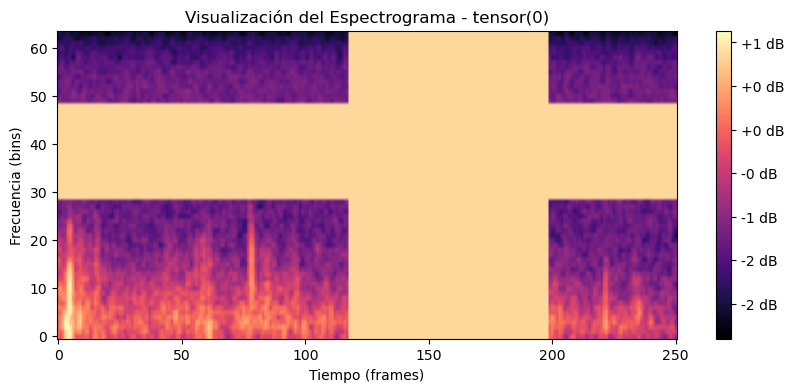

In [22]:
import matplotlib.pyplot as plt

sample, label = dataset.__getitem__(1000)


sample_np = sample.squeeze().detach().cpu().numpy()

plt.figure(figsize=(10, 4))
# origin='lower' para que las frecuencias bajas queden abajo
plt.imshow(sample_np, aspect='auto', origin='lower', cmap='magma')

plt.title('Visualización del Espectrograma - ' + str(label))
plt.xlabel('Tiempo (frames)')
plt.ylabel('Frecuencia (bins)')
plt.colorbar(format='%+2.0f dB')
plt.show()

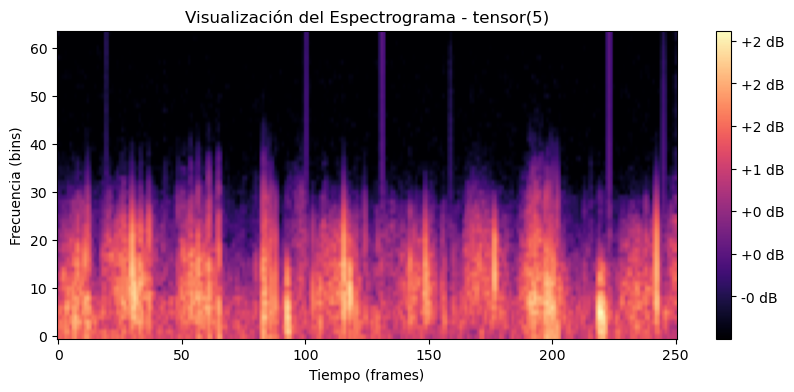

In [ ]:
import matplotlib.pyplot as plt

sample, label = test_dataset.__getitem__(1000)


sample_np = sample.squeeze().detach().cpu().numpy()

plt.figure(figsize=(10, 4))
# origin='lower' para que las frecuencias bajas queden abajo
plt.imshow(sample_np, aspect='auto', origin='lower', cmap='magma')

plt.title('Visualización del Espectrograma - ' + str(label))
plt.xlabel('Tiempo (frames)')
plt.ylabel('Frecuencia (bins)')
plt.colorbar(format='%+2.0f dB')
plt.show()

# Training loop
---

In [4]:
%load_ext autoreload
%autoreload 2


import sys
sys.path.insert(0, "..")  

import models.networks   # registra EfficientNet, ResNet en MODEL_REGISTRY
from models.base import MODEL_REGISTRY
from pipeline_api import load_dataset
from train import objective, resolve_device, parse_args
import optuna
import argparse
from pipeline_api import load_dataset
import wandb
wandb.login()

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


False

In [5]:
test_dataset = load_dataset("../data/processed/test")
train_dataset = load_dataset("../data/processed/train")

print(train_dataset)
print(test_dataset)
print("Modelos disponibles:", list(MODEL_REGISTRY.keys()))

✓ Dataset cargado desde '..\data\processed\test'
  BioCASDataset(n=4706, n_classes=7, feature_shape=(1, 64, 251), mode=lazy (per-file))
✓ Dataset cargado desde '..\data\processed\train'
  BioCASDataset(n=19862, n_classes=7, feature_shape=(1, 64, 251), mode=lazy (per-file))
BioCASDataset(n=19862, n_classes=7, feature_shape=(1, 64, 251), mode=lazy (per-file))
BioCASDataset(n=4706, n_classes=7, feature_shape=(1, 64, 251), mode=lazy (per-file))
Modelos disponibles: ['efficientnet_b0', 'resnet18']


In [6]:
# sin optuna

args = argparse.Namespace(
    model          = "efficientnet_b0",
    n_epochs       = 5,
    lr             = 1e-3,
    weight_decay   = 1e-4,
    batch_size     = 256,
    num_workers    = 0,
    device         = "cuda",
    seed           = 42,
    wandb_project  = "biocas",
    wandb_group    = "debug",
    log_image_every= 2,
)

best_acc = objective(None, train_dataset, test_dataset, args)
print(f"Val acc: {best_acc:.2f}%")

Epoch   1/5 | train_loss=1.1652 train_acc=54.28% | val_loss=2.3776 val_acc=5.38%


Epoch   2/5 | train_loss=0.6558 train_acc=75.61% | val_loss=3.7898 val_acc=6.23%


Epoch   3/5 | train_loss=0.4360 train_acc=82.23% | val_loss=2.8618 val_acc=25.73%


Epoch   4/5 | train_loss=0.2650 train_acc=87.47% | val_loss=3.9150 val_acc=27.11%


Epoch   5/5 | train_loss=0.1749 train_acc=90.84% | val_loss=4.1097 val_acc=27.43%


epoch,▁▃▃▅▆▆██
lr,█▆▄▂▁
train/acc,▁▅▆▇█
train/loss,█▄▃▂▁
val/acc,▁▁▇██
val/loss,▁▇▃▇█
epoch,5
lr,0
train/acc,90.84181
train/loss,0.17492
val/acc,27.43306


Val acc: 27.43%


In [8]:
# con optuna

args.n_epochs       = 30
args.wandb_group    = "optuna-run-1"
args.log_image_every= 10

pruner = optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=5)
study  = optuna.create_study(direction="maximize", pruner=pruner)

study.optimize(
    lambda trial: objective(trial, train_dataset, test_dataset, args),
    n_trials=10,
    show_progress_bar=True,
)

# Ver resultados
study.best_trial.params

[I 2026-07-21 21:45:09,637] A new study created in memory with name: no-name-f5591d64-b902-4911-94a8-97322c51967b


  0%|          | 0/10 [00:00<?, ?it/s]

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\camsp/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 106MB/s]


Epoch   1/30 | train_loss=1.8544 train_acc=23.74% | val_loss=9.2881 val_acc=0.45%


Epoch   2/30 | train_loss=1.4600 train_acc=33.07% | val_loss=1.7620 val_acc=40.61%


Epoch   3/30 | train_loss=1.2286 train_acc=44.47% | val_loss=1.9854 val_acc=7.80%


Epoch   4/30 | train_loss=1.0850 train_acc=52.56% | val_loss=6.6527 val_acc=0.40%


[W 2026-07-21 21:50:32,235] Trial 0 failed with parameters: {'model': 'resnet18', 'lr': 0.004963834644362697, 'weight_decay': 0.0015418133448993603, 'batch_size': 512, 'dropout': 0.024181519812774444} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\camsp\anaconda3\envs\hinf\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\camsp\AppData\Local\Temp\ipykernel_12780\4246261067.py", line 11, in <lambda>
    lambda trial: objective(trial, train_dataset, test_dataset, args),
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\camsp\Documents\Universidad\Semillero\biocas_classifier\workflow\train.py", line 291, in objective
    train_metrics = train_epoch(
                    ^^^^^^^^^^^^
  File "c:\Users\camsp\Documents\Universidad\Semillero\biocas_classifier\workflow\train.py", line 93, in train_e

KeyboardInterrupt: 

## Results

In [ ]:
import optuna.visualization as vis

vis.plot_param_importances(study).show()
vis.plot_optimization_history(study).show()
vis.plot_parallel_coordinate(study).show()

NameError: name 'study' is not defined